# 04. cosipy による画像再構成 (目標 5)

画像再構成は **cosipy をそのまま使います**。`Toy3MLplugin` が用意するのは cosipy に差し込む
**データインタフェース** `DataIF_ToyScan` だけ。正式な入口 `ImageDeconvolution` に、
データセットと **YAML パラメータファイル**(`examples/imagedeconvolution_toy.yml`)を渡して回します。

> このノートは `cosipy` が必要: `pip install Toy3MLplugin[cosipy]` 等。

In [1]:
import logging; logging.disable(logging.INFO)
import numpy as np, healpy as hp
import matplotlib.pyplot as plt

from Toy3MLplugin.cosipy_dataif import build_toy_scan_dataif
from cosipy.image_deconvolution import ImageDeconvolution

NSIDE = 4
npix = hp.nside2npix(NSIDE)
l, b = hp.pix2ang(NSIDE, np.arange(npix), lonlat=True)
truth = np.zeros(npix)
truth[np.argmin((l-10)**2 + b**2)] = 1.0e-2
truth[np.argmin((l-60)**2 + b**2)] = 5.0e-3

18:48:41 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=2795658;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=2795659;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=2795665;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=2795666;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=2795673;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=2795674;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

18:48:41 WARNING   WARNINGs here are NOT errors                                                      ]8;id=2795681;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=2795682;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#45\45]8;;\

         WARNING   but are inform you about optional packages that can be installed                  ]8;id=2795688;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=2795689;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#46\46]8;;\

...

18:48:42 WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=2795724;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=2795725;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

         WARNING   No fermitools installed                                              ]8;id=2795732;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=2795733;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=2795739;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=2795740;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=2795745;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=2795746;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=2795751;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=2795752;file:///Users/yoneda/Work/Exp/threeML/3ML/lib/python3.13/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

In [2]:
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

### 2軌道のトイ DataIF を作る(背景つき)

In [3]:
datasets = [
    build_toy_scan_dataif("orbitA", NSIDE, truth, np.linspace(0, 90, 90),
                          dwell=400.0, fov_sigma=10.0, bkg_level=0.5, seed=1),
    build_toy_scan_dataif("orbitB", NSIDE, truth, np.linspace(20, 110, 90),
                          dwell=400.0, fov_sigma=10.0, bkg_level=0.5, seed=2),
]
print("event counts:", [int(np.sum(d.event.contents)) for d in datasets])

event counts: [183, 115]


### cosipy の ImageDeconvolution を YAML 設定で実行

  0%|          | 0/100 [00:00<?, ?it/s]

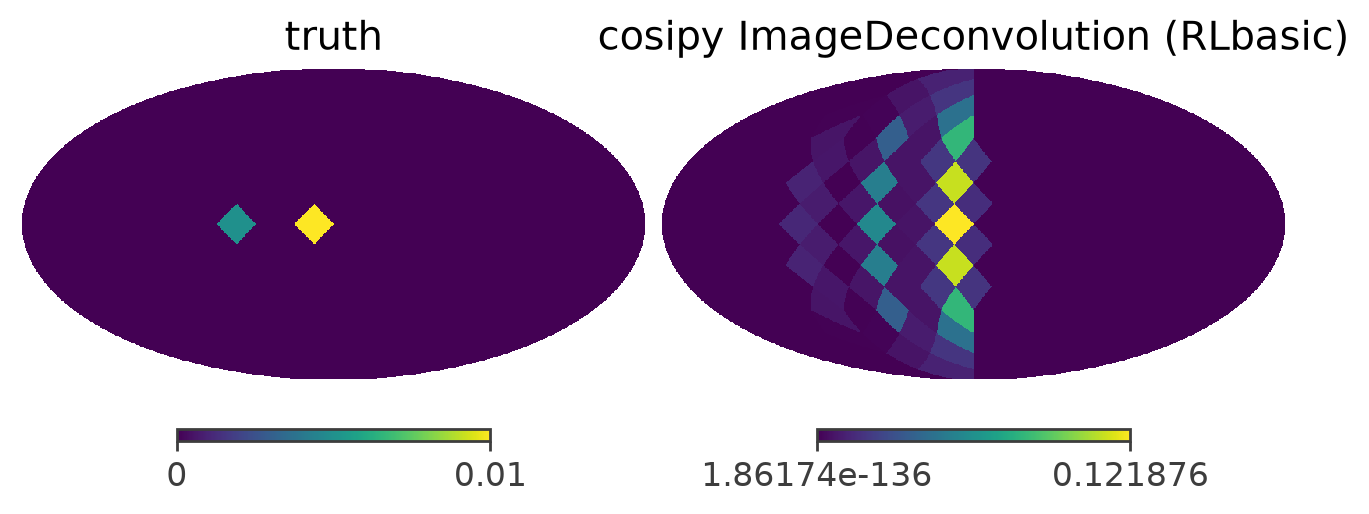

brightest reconstructed pixels:
  l= 11.2 b=  0.0  flux=1.22e-01
  l= 11.2 b= 19.5  flux=1.12e-01


In [4]:
imdec = ImageDeconvolution()
imdec.set_dataset(datasets)
imdec.read_parameterfile("imagedeconvolution_toy.yml")   # model/algorithm を YAML で指定
imdec.initialize()
imdec.run_deconvolution()

rec = np.asarray(imdec.results[-1]["model"].contents).ravel()
hp.mollview(truth, title="truth", sub=(1,2,1), cmap="viridis")
hp.mollview(rec,   title="cosipy ImageDeconvolution (RLbasic)", sub=(1,2,2), cmap="viridis")
plt.show()

print("brightest reconstructed pixels:")
for k in np.argsort(rec)[-2:][::-1]:
    print(f"  l={l[k]:5.1f} b={b[k]:5.1f}  flux={rec[k]:.2e}")